# Variable Tracking (Fixed Length)

Перезапуск `variables_tracking/` без экстраполяции по длине: все сплиты имеют одну и ту же фиксированную длину программы.


## 0. Setup


In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
personal_token = user_secrets.get_secret("GITHUB_TOKEN")

# !rm -rf transformer-analyzing
!git clone https://{personal_token}@github.com/maximvw/transformer-analyzing.git transformer-analyzing
%cd transformer-analyzing

Cloning into 'transformer-analyzing'...
remote: Enumerating objects: 561, done.
remote: Counting objects: 100% (223/223), done.
remote: Compressing objects: 100% (173/173), done.
remote: Total 561 (delta 85), reused 164 (delta 48), pack-reused 338 (from 1)
Receiving objects: 100% (561/561), 17.71 MiB | 31.65 MiB/s, done.
Resolving deltas: 100% (232/232), done.
/kaggle/working/transformer-analyzing


In [2]:
import os
import sys
from pathlib import Path
import json

import torch

print("Python:", sys.executable)
PYTHON = sys.executable
print("CUDA available:", torch.cuda.is_available())
print("CUDA devices:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {props.name} | {props.total_memory / 1e9:.1f} GB")

ROOT = Path.cwd()


Python: /usr/bin/python3
CUDA available: False
CUDA devices: 0


## 0. Конфиг

Сверху есть переключатель `CONFIG_MODE`: `"smoke"` для быстрой проверки запуска и `"full"` для основного fixed-length эксперимента.


In [3]:
CONFIG_MODE = "full"  # "smoke" | "full"

SMOKE_CONFIG = {
    "fixed_len": 8,
    "max_value": 16,
    "n_train": 512,
    "n_val": 64,
    "n_test": 64,
    "sft_layers": [2, 4],
    "d_model": 16,
    "n_head": 4,
    "batch_size": 32,
    "epochs": 2,
    "patience": 1,
    "lr": 1e-4,
    "aux_lambda": 5.0,
    "max_seq_len": 64,
}

FULL_CONFIG = {
    "fixed_len": 16,
    "max_value": 32,
    "n_train": 80000,
    "n_val": 1000,
    "n_test": 1000,
    "sft_layers": [2, 4, 6],
    "d_model": 128,
    "n_head": 4,
    "batch_size": 128,
    "epochs": 100,
    "patience": 25,
    "lr": 1e-4,
    "aux_lambda": 20.0,
    "max_seq_len": 64,
}

CONFIGS = {
    "smoke": SMOKE_CONFIG,
    "full": FULL_CONFIG,
}
assert CONFIG_MODE in CONFIGS, f"Unknown CONFIG_MODE: {CONFIG_MODE}"
CFG = CONFIGS[CONFIG_MODE]

FIXED_LEN = CFG["fixed_len"]
MIN_LEN = FIXED_LEN
MAX_LEN = FIXED_LEN
OOD_MIN_LEN = FIXED_LEN
OOD_MAX_LEN = FIXED_LEN
MAX_VALUE = CFG["max_value"]
N_TRAIN = CFG["n_train"]
N_VAL = CFG["n_val"]
N_TEST = CFG["n_test"]
SFT_LAYERS = CFG["sft_layers"]
D_MODEL = CFG["d_model"]
N_HEAD = CFG["n_head"]
BATCH_SIZE = CFG["batch_size"]
EPOCHS = CFG["epochs"]
PATIENCE = CFG["patience"]
LR = CFG["lr"]
AUX_LAMBDA = CFG["aux_lambda"]
MAX_SEQ_LEN = CFG["max_seq_len"]

RUN_TAG = f"{CONFIG_MODE}_fixed_len_{FIXED_LEN}"
DATA_DIR = ROOT / "variables_tracking" / f"data_{RUN_TAG}"
CKPT_DIR = ROOT / "checkpoints" / f"variables_tracking_{RUN_TAG}"
DATA_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f"CONFIG_MODE={CONFIG_MODE}")
print(json.dumps(CFG, indent=2))
print("DATA_DIR:", DATA_DIR)
print("CKPT_DIR:", CKPT_DIR)


CONFIG_MODE=full
{
  "fixed_len": 16,
  "max_value": 32,
  "n_train": 80000,
  "n_val": 1000,
  "n_test": 1000,
  "sft_layers": [
    2,
    4,
    6
  ],
  "d_model": 128,
  "n_head": 4,
  "batch_size": 128,
  "epochs": 100,
  "patience": 25,
  "lr": 0.0001,
  "aux_lambda": 20.0,
  "max_seq_len": 64
}
DATA_DIR: /kaggle/working/transformer-analyzing/variables_tracking/data_full_fixed_len_16
CKPT_DIR: /kaggle/working/transformer-analyzing/checkpoints/variables_tracking_full_fixed_len_16


## 1. Генерация данных

Все train/val/test/OOD-сплиты генерируются с одной и той же длиной `FIXED_LEN`.


In [4]:
!$PYTHON -m variables_tracking.scripts.generate_data \
    --output_dir "$DATA_DIR" \
    --n_train $N_TRAIN \
    --n_val $N_VAL \
    --n_test $N_TEST \
    --min_len $MIN_LEN \
    --max_len $MAX_LEN \
    --ood_min_len $OOD_MIN_LEN \
    --ood_max_len $OOD_MAX_LEN \
    --max_value $MAX_VALUE \
    --seed 42


train: n=80000 | len=[16, 16] | avg_len=16.00 | avg_depth=3.06 | types={'random': 80000}
val: n=1000 | len=[16, 16] | avg_len=16.00 | avg_depth=3.04 | types={'random': 1000}
test_id: n=1000 | len=[16, 16] | avg_len=16.00 | avg_depth=3.11 | types={'random': 1000}
test_ood_long: n=1000 | len=[16, 16] | avg_len=16.00 | avg_depth=3.32 | types={'overwrite_heavy': 1000}
test_ood_chain: n=1000 | len=[16, 16] | avg_len=16.00 | avg_depth=16.00 | types={'chain': 1000}
test_ood_distractor: n=1000 | len=[16, 16] | avg_len=16.00 | avg_depth=5.00 | types={'distractor': 1000}
test_ood_copy_heavy: n=1000 | len=[16, 16] | avg_len=16.00 | avg_depth=6.12 | types={'copy_heavy': 1000}
test_ood_arithmetic: n=1000 | len=[16, 16] | avg_len=16.00 | avg_depth=6.22 | types={'arithmetic_heavy': 1000}


In [5]:
import json

for path in sorted(DATA_DIR.glob("*.json")):
    with open(path) as f:
        items = json.load(f)
    print(f"{path.name}: {len(items)} examples")
    if items:
        lengths = sorted({item["length"] for item in items})
        ex = items[0]
        print("  unique lengths:", lengths)
        print("  sample length:", ex["length"], "query:", ex["query_var"], "answer:", ex["answer"], "type:", ex["program_type"])
        print("  sample program:", " ".join(ex["program"][:6]))


test_id.json: 1000 examples
  unique lengths: [16]
  sample length: 16 query: x answer: 25 type: random
  sample program: DEC(x) SET(y,18) SET(x,0) SET(z,24) DEC(z) COPY(z,z)
test_ood_arithmetic.json: 1000 examples
  unique lengths: [16]
  sample length: 16 query: x answer: 12 type: arithmetic_heavy
  sample program: SET(x,22) SET(y,26) SET(z,7) SET(w,20) ADDC(x,z,9) ADDC(w,y,18)
test_ood_chain.json: 1000 examples
  unique lengths: [16]
  sample length: 16 query: y answer: 14 type: chain
  sample program: SET(w,2) ADDC(y,w,9) COPY(x,y) ADDC(z,x,3) COPY(x,z) ADDC(z,x,5)
test_ood_copy_heavy.json: 1000 examples
  unique lengths: [16]
  sample length: 16 query: w answer: 21 type: copy_heavy
  sample program: SET(y,19) ADDC(x,y,12) ADDC(z,x,27) COPY(w,z) SET(x,6) COPY(z,x)
test_ood_distractor.json: 1000 examples
  unique lengths: [16]
  sample length: 16 query: x answer: 23 type: distractor
  sample program: SET(x,27) INC(x) INC(x) ADDC(x,x,24) ADDC(x,x,2) ADD(w,y,y)
test_ood_long.json: 100

## 2. Обучение SFT baseline


In [6]:
for n_layer in SFT_LAYERS:
    print(f"\n{'=' * 70}")
    print(f"Training Variable Tracking SFT {n_layer}L | fixed_len={FIXED_LEN}")
    print(f"{'=' * 70}")
    SAVE_DIR = CKPT_DIR / f"variables_sft_{n_layer}L"
    !"$PYTHON" -m variables_tracking.src.train \
        --train_path "{DATA_DIR / 'train.json'}" \
        --val_path "{DATA_DIR / 'val.json'}" \
        --max_value {MAX_VALUE} \
        --d_model {D_MODEL} --n_layer {n_layer} --n_head {N_HEAD} \
        --max_seq_len {MAX_SEQ_LEN} \
        --lr {LR} --weight_decay 0.01 \
        --batch_size {BATCH_SIZE} --epochs {EPOCHS} --patience {PATIENCE} \
        --lambda_state 0.0 \
        --num_workers 2 \
        --save_dir "{SAVE_DIR}" \
        --seed 42



Training Variable Tracking SFT 2L | fixed_len=16
Device: cpu
Vocab size: 769
Model parameters: 507,552
Train:   0%|                                            | 0/625 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch   0 | train loss=3.3603 acc=0.1056 | val loss=3.2503 acc=0.1380
Epoch   1 | train loss=3.1719 acc=0.1698 | val loss=3.1806 acc=0.1600
Epoch   2 | train loss=3.1062 acc=0.1794 | val loss=3.1766 acc=0.1670
Epoch   3 | train loss=3.0676 acc=0.1840 | val loss=3.1769 acc=0.1650
Epoch   4 | train loss=3.0393 acc=0.1872 | val loss=3.1726 acc=0.1670
Epoch   5 | train loss=3.0147 acc=0.1908 | val loss=3.1808 acc=0.1560
Epoch   6 | train loss=2.9931 acc=0.1949 | val loss=3.1879 acc=0.1610
Epoch   7 | train loss=2.9717 acc=0.1983 | val loss=3.1971 acc=0.1600
Epoch   8 | train loss=2.9500 ac

## 3. Обучение 2L + Auxiliary Loss


In [7]:
SAVE_DIR = CKPT_DIR / "variables_aux_2L"

!"$PYTHON" -m variables_tracking.src.train \
    --train_path "{DATA_DIR / 'train.json'}" \
    --val_path "{DATA_DIR / 'val.json'}" \
    --max_value {MAX_VALUE} \
    --d_model {D_MODEL} --n_layer 2 --n_head {N_HEAD} \
    --max_seq_len {MAX_SEQ_LEN} \
    --lr {LR} --weight_decay 0.01 \
    --batch_size {BATCH_SIZE} --epochs {EPOCHS} --patience {PATIENCE} \
    --lambda_state {AUX_LAMBDA} \
    --num_workers 2 \
    --save_dir "{SAVE_DIR}" \
    --seed 42


Device: cpu
Vocab size: 769
Model parameters: 507,552
Probe parameters: 16,896
Train:   0%|                                            | 0/625 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch   0 | train loss=58.2494 acc=0.0895 | val loss=54.0891 acc=0.0930
Epoch   1 | train loss=51.9639 acc=0.0965 | val loss=50.9603 acc=0.0970
Epoch   2 | train loss=49.0786 acc=0.1232 | val loss=48.1042 acc=0.1480
Epoch   3 | train loss=45.8989 acc=0.2170 | val loss=44.6704 acc=0.2580
Epoch   4 | train loss=42.5758 acc=0.3059 | val loss=41.5782 acc=0.3090
Epoch   5 | train loss=39.7845 acc=0.3456 | val loss=39.1058 acc=0.3190
Epoch   6 | train loss=37.6480 acc=0.3644 | val loss=37.3010 acc=0.3410
Epoch   7 | train loss=36.0512 acc=0.3775 | val loss=35.9089 acc=0.3610
Epoch   8 | train loss=34.7568 acc=0.3890

## 4. Evaluation


In [8]:
from variables_tracking.src.evaluate import evaluate_all

all_eval = {}
variables = ["x", "y", "z", "w"]

for n_layer in SFT_LAYERS:
    name = f"SFT {n_layer}L"
    print(f"\n{'=' * 70}")
    print(name)
    print(f"{'=' * 70}")
    all_eval[name] = evaluate_all(
        checkpoint_path=str(CKPT_DIR / f"variables_sft_{n_layer}L" / "checkpoint_best.pt"),
        data_dir=str(DATA_DIR),
        variables=variables,
        max_value=MAX_VALUE,
        batch_size=BATCH_SIZE,
        lambda_state=0.0,
        d_model=D_MODEL,
        n_layer=n_layer,
        n_head=N_HEAD,
        max_seq_len=MAX_SEQ_LEN,
    )

print(f"\n{'=' * 70}")
print("2L + Aux")
print(f"{'=' * 70}")
all_eval["2L + Aux"] = evaluate_all(
    checkpoint_path=str(CKPT_DIR / "variables_aux_2L" / "checkpoint_best.pt"),
    data_dir=str(DATA_DIR),
    variables=variables,
    max_value=MAX_VALUE,
    batch_size=BATCH_SIZE,
    lambda_state=AUX_LAMBDA,
    d_model=D_MODEL,
    n_layer=2,
    n_head=N_HEAD,
    max_seq_len=MAX_SEQ_LEN,
)



SFT 2L
test_id: accuracy=0.1860 loss=3.1396 (n=1000)
test_ood_arithmetic: accuracy=0.0490 loss=3.6053 (n=1000)
test_ood_chain: accuracy=0.0290 loss=3.7066 (n=1000)
test_ood_copy_heavy: accuracy=0.3080 loss=2.8779 (n=1000)
test_ood_distractor: accuracy=0.0320 loss=3.7640 (n=1000)
test_ood_long: accuracy=0.0420 loss=3.5389 (n=1000)

SFT 4L
test_id: accuracy=0.1790 loss=3.1438 (n=1000)
test_ood_arithmetic: accuracy=0.0420 loss=3.5591 (n=1000)
test_ood_chain: accuracy=0.0250 loss=3.6714 (n=1000)
test_ood_copy_heavy: accuracy=0.3450 loss=2.8758 (n=1000)
test_ood_distractor: accuracy=0.0310 loss=3.7356 (n=1000)
test_ood_long: accuracy=0.0500 loss=3.5077 (n=1000)

SFT 6L
test_id: accuracy=0.1920 loss=3.1506 (n=1000)
test_ood_arithmetic: accuracy=0.0360 loss=3.5807 (n=1000)
test_ood_chain: accuracy=0.0360 loss=3.6571 (n=1000)
test_ood_copy_heavy: accuracy=0.3120 loss=2.9114 (n=1000)
test_ood_distractor: accuracy=0.0360 loss=3.7101 (n=1000)
test_ood_long: accuracy=0.0310 loss=3.5175 (n=1000)



In [9]:
import pandas as pd

rows = []
for name, results in all_eval.items():
    row = {"Model": name}
    for split_name, metrics in results.items():
        row[split_name] = f"{metrics['accuracy']:.1%}"
    rows.append(row)
df = pd.DataFrame(rows)
df


,Model,test_id,test_ood_arithmetic,test_ood_chain,test_ood_copy_heavy,test_ood_distractor,test_ood_long
0,SFT 2L,18.6%,4.9%,2.9%,30.8%,3.2%,4.2%
1,SFT 4L,17.9%,4.2%,2.5%,34.5%,3.1%,5.0%
2,SFT 6L,19.2%,3.6%,3.6%,31.2%,3.6%,3.1%
3,2L + Aux,53.4%,3.4%,3.2%,42.9%,5.9%,20.5%


## 5. Training Curves


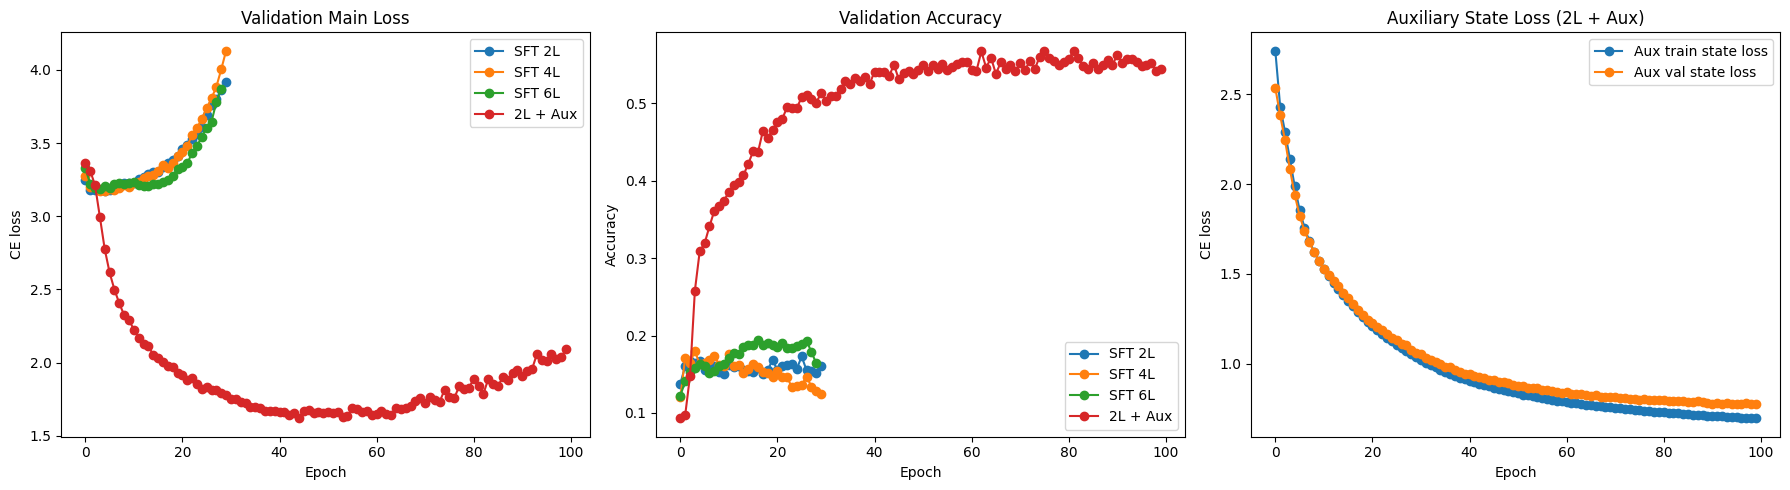

In [10]:
import matplotlib.pyplot as plt

def load_log(path):
    with open(path) as f:
        return json.load(f)

logs = {
    **{
        f"SFT {n_layer}L": load_log(CKPT_DIR / f"variables_sft_{n_layer}L" / "train_log.json")
        for n_layer in SFT_LAYERS
    },
    "2L + Aux": load_log(CKPT_DIR / "variables_aux_2L" / "train_log.json"),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label, log in logs.items():
    epochs = [row["epoch"] for row in log]
    val_acc = [row["val"]["accuracy"] for row in log]
    val_main = [row["val"]["loss_main"] for row in log]
    axes[0].plot(epochs, val_main, marker="o", label=label)
    axes[1].plot(epochs, val_acc, marker="o", label=label)

aux_log = logs["2L + Aux"]
aux_epochs = [row["epoch"] for row in aux_log]
aux_train_state = [row["train"]["loss_state"] for row in aux_log]
aux_val_state = [row["val"]["loss_state"] for row in aux_log]
axes[2].plot(aux_epochs, aux_train_state, marker="o", label="Aux train state loss")
axes[2].plot(aux_epochs, aux_val_state, marker="o", label="Aux val state loss")

axes[0].set_title("Validation Main Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CE loss")
axes[0].legend()

axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

axes[2].set_title("Auxiliary State Loss (2L + Aux)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("CE loss")
axes[2].legend()

plt.tight_layout()
plt.show()


## 6. Same-Length Comparison


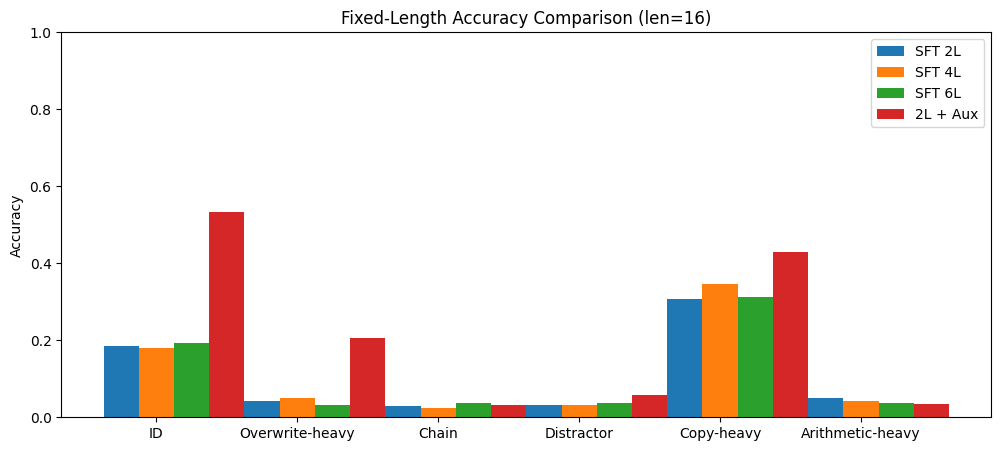

In [11]:
import numpy as np

splits = [
    "test_id",
    "test_ood_long",
    "test_ood_chain",
    "test_ood_distractor",
    "test_ood_copy_heavy",
    "test_ood_arithmetic",
]
labels = ["ID", "Overwrite-heavy", "Chain", "Distractor", "Copy-heavy", "Arithmetic-heavy"]
model_names = list(all_eval.keys())

x = np.arange(len(splits))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for idx, model_name in enumerate(model_names):
    values = [all_eval[model_name][split]["accuracy"] for split in splits]
    ax.bar(x + idx * width - width, values, width=width, label=model_name)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title(f"Fixed-Length Accuracy Comparison (len={FIXED_LEN})")
ax.legend()
plt.show()


## 7. Accuracy by Program Length

Санити-чек: в fixed-length режиме график должен выродиться в одну точку на модель.


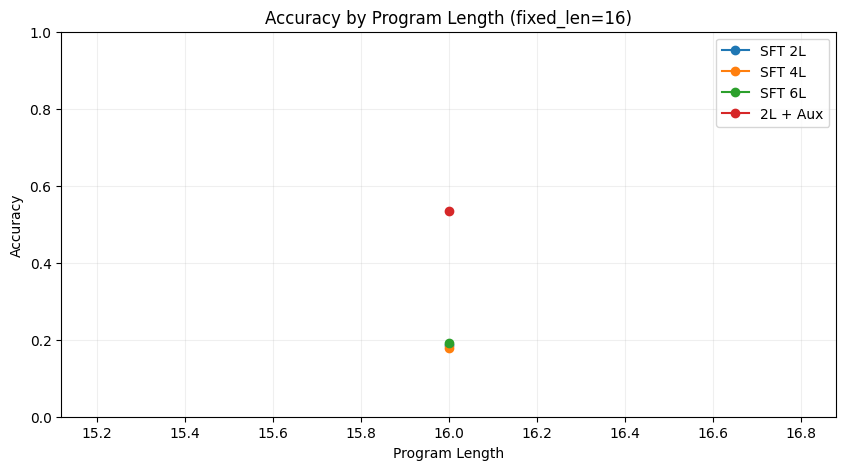

In [12]:
from collections import defaultdict
from torch.utils.data import DataLoader

from variables_tracking.src.data import VariableTrackingDataset, collate_fn
from variables_tracking.src.evaluate import load_checkpoint
from variables_tracking.src.tokenizer import VariableTrackingTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = VariableTrackingTokenizer(variables=variables, max_value=MAX_VALUE)
test_ds = VariableTrackingDataset(DATA_DIR / "test_id.json", tokenizer)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

def load_model_bundle(ckpt_path, n_layer, lambda_state):
    model, probe = load_checkpoint(
        checkpoint_path=ckpt_path,
        tokenizer=tokenizer,
        device=device,
        max_value=MAX_VALUE,
        d_model=D_MODEL,
        n_layer=n_layer,
        n_head=N_HEAD,
        max_seq_len=MAX_SEQ_LEN,
    )
    model.eval()
    if probe is not None:
        probe.eval()
    return model, probe, lambda_state

bundles = {}
for n_layer in SFT_LAYERS:
    label = f"SFT {n_layer}L"
    ckpt_path = CKPT_DIR / f"variables_sft_{n_layer}L" / "checkpoint_best.pt"
    if ckpt_path.exists():
        bundles[label] = load_model_bundle(ckpt_path, n_layer, 0.0)
    else:
        print(f"Skipping {label}: checkpoint not found at {ckpt_path}")

aux_ckpt_path = CKPT_DIR / "variables_aux_2L" / "checkpoint_best.pt"
if aux_ckpt_path.exists():
    bundles["2L + Aux"] = load_model_bundle(aux_ckpt_path, 2, AUX_LAMBDA)
else:
    print(f"Skipping 2L + Aux: checkpoint not found at {aux_ckpt_path}")

if not bundles:
    raise FileNotFoundError(f"No checkpoints found in {CKPT_DIR}")

@torch.no_grad()
def accuracy_by_length(model):
    buckets = defaultdict(lambda: [0, 0])
    for batch in test_loader:
        ids = batch["input_ids"].to(device)
        ans_pos = batch["ans_pos"].to(device)
        hidden, _ = model(ids, ids != 0)
        logits = model.classifier(hidden[torch.arange(ids.size(0), device=device), ans_pos])
        preds = logits.argmax(dim=-1).cpu()
        for i in range(ids.size(0)):
            length = batch["program_length"][i].item()
            ok = int(preds[i].item() == batch["targets"][i].item())
            buckets[length][0] += ok
            buckets[length][1] += 1
    xs = sorted(buckets)
    ys = [buckets[x][0] / buckets[x][1] for x in xs]
    return xs, ys

plt.figure(figsize=(10, 5))
for label, (model, probe, lam) in bundles.items():
    xs, ys = accuracy_by_length(model)
    plt.plot(xs, ys, marker="o", label=label)
plt.xlabel("Program Length")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.0)
plt.title(f"Accuracy by Program Length (fixed_len={FIXED_LEN})")
#  vs Program Length (OOD Long)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 8. OOD Heatmaps

Две удобные картинки для защиты: абсолютная accuracy по split'ам и падение относительно ID.

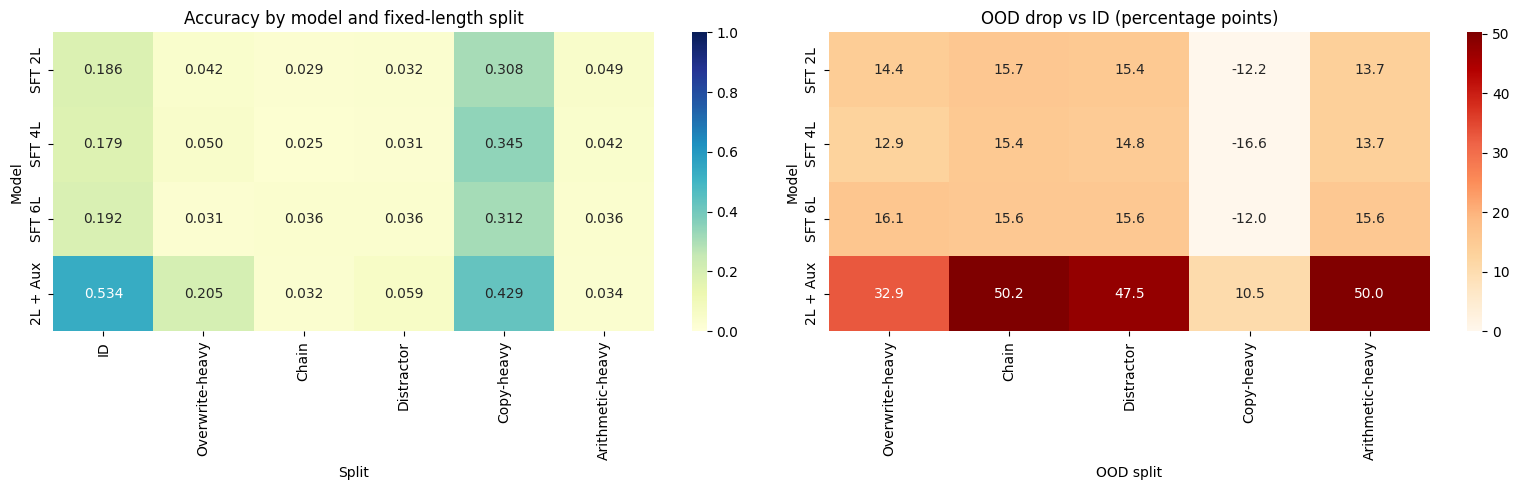

In [13]:
import seaborn as sns

split_order = [
    "test_id",
    "test_ood_long",
    "test_ood_chain",
    "test_ood_distractor",
    "test_ood_copy_heavy",
    "test_ood_arithmetic",
]
split_labels = {
    "test_id": "ID",
    "test_ood_long": "Overwrite-heavy",
    "test_ood_chain": "Chain",
    "test_ood_distractor": "Distractor",
    "test_ood_copy_heavy": "Copy-heavy",
    "test_ood_arithmetic": "Arithmetic-heavy",
}

heatmap_df = pd.DataFrame(
    {
        model_name: {
            split_labels[split]: all_eval[model_name][split]["accuracy"]
            for split in split_order
            if split in all_eval[model_name]
        }
        for model_name in all_eval
    }
).T

id_scores = heatmap_df["ID"]
drop_df = heatmap_df.apply(lambda col: id_scores - col)
drop_df = drop_df[[label for key, label in split_labels.items() if label != "ID"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0.0, vmax=1.0, ax=axes[0])
axes[0].set_title("Accuracy by model and fixed-length split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Model")

sns.heatmap(drop_df * 100, annot=True, fmt=".1f", cmap="OrRd", vmin=0.0, ax=axes[1])
axes[1].set_title("OOD drop vs ID (percentage points)")
axes[1].set_xlabel("OOD split")
axes[1].set_ylabel("Model")

plt.tight_layout()
plt.show()


## 9. Accuracy by Dependency Depth

Это уже ближе к сути алгоритмической генерализации: одинаковая длина программы, но разная глубина зависимости до целевой переменной.

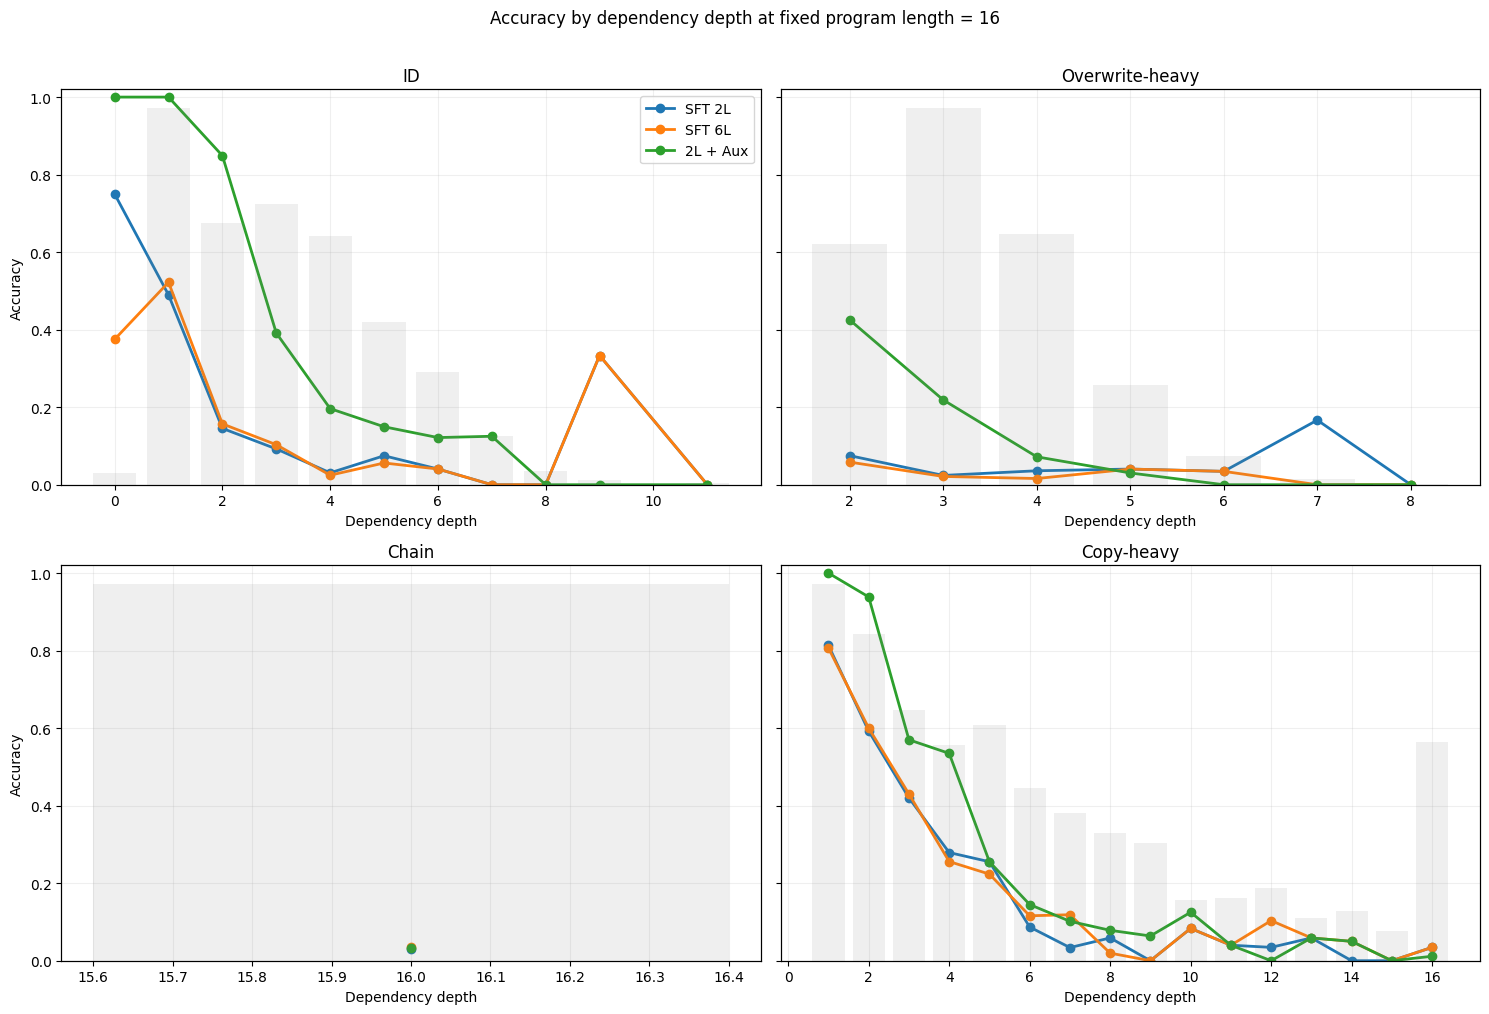

In [14]:
split_files = {
    "ID": DATA_DIR / "test_id.json",
    "Overwrite-heavy": DATA_DIR / "test_ood_long.json",
    "Chain": DATA_DIR / "test_ood_chain.json",
    "Copy-heavy": DATA_DIR / "test_ood_copy_heavy.json",
    "Arithmetic-heavy": DATA_DIR / "test_ood_arithmetic.json",
}

representative_models = {}
if SFT_LAYERS:
    first_sft = f"SFT {SFT_LAYERS[0]}L"
    last_sft = f"SFT {SFT_LAYERS[-1]}L"
    if first_sft in bundles:
        representative_models[first_sft] = bundles[first_sft]
    if last_sft in bundles and last_sft != first_sft:
        representative_models[last_sft] = bundles[last_sft]
if "2L + Aux" in bundles:
    representative_models["2L + Aux"] = bundles["2L + Aux"]

if not representative_models:
    raise FileNotFoundError("No representative checkpoints available for dependency-depth plots")

@torch.no_grad()
def accuracy_by_dependency_depth(model, dataset_path):
    dataset = VariableTrackingDataset(dataset_path, tokenizer, num_vars=len(variables))
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    buckets = defaultdict(lambda: [0, 0])
    for batch in loader:
        ids = batch["input_ids"].to(device)
        ans_pos = batch["ans_pos"].to(device)
        hidden, _ = model(ids, ids != 0)
        logits = model.classifier(hidden[torch.arange(ids.size(0), device=device), ans_pos])
        preds = logits.argmax(dim=-1).cpu()
        for i in range(ids.size(0)):
            depth = int(batch["dependency_depth"][i].item())
            ok = int(preds[i].item() == batch["targets"][i].item())
            buckets[depth][0] += ok
            buckets[depth][1] += 1
    xs = sorted(buckets)
    ys = [buckets[x][0] / buckets[x][1] for x in xs]
    counts = [buckets[x][1] for x in xs]
    return xs, ys, counts

selected_splits = ["ID", "Overwrite-heavy", "Chain", "Copy-heavy"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axes = axes.flatten()

for ax, split_name in zip(axes, selected_splits):
    for model_name, (model, probe, lam) in representative_models.items():
        xs, ys, counts = accuracy_by_dependency_depth(model, split_files[split_name])
        ax.plot(xs, ys, marker="o", linewidth=2, label=model_name)
    ref_model = next(iter(representative_models.values()))[0]
    ref_xs, _, ref_counts = accuracy_by_dependency_depth(ref_model, split_files[split_name])
    ax2 = ax.twinx()
    ax2.bar(ref_xs, ref_counts, alpha=0.12, color="gray", width=0.8)
    ax2.set_yticks([])
    ax.set_title(split_name)
    ax.set_xlabel("Dependency depth")
    ax.set_ylim(0.0, 1.02)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Accuracy")
axes[2].set_ylabel("Accuracy")
axes[0].legend()
plt.suptitle(f"Accuracy by dependency depth at fixed program length = {FIXED_LEN}", y=1.01)
plt.tight_layout()
plt.show()
